In [7]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import sys
sys.path.insert(0, "/home/wfrederick/project1ml4h/libs")

from umap import UMAP
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

In [8]:
test_embeddings = np.load("test_embeddings.npy")
test_labels     = np.load("test_labels.npy")
cluster_labels  = np.load("cluster_labels.npy")

print(f"Embeddings shape: {test_embeddings.shape}")
print(f"Labels shape:     {test_labels.shape}")
print(f"Cluster labels:   {cluster_labels.shape}")

Embeddings shape: (4000, 4096)
Labels shape:     (4000,)
Cluster labels:   (4000,)


In [9]:
print("Running UMAP...")
reducer = UMAP(n_components=2, random_state=42)
umap_reduced = reducer.fit_transform(test_embeddings)
print(f"UMAP output shape: {umap_reduced.shape}")

Running UMAP...


/home/wfrederick/project1ml4h/libs/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP output shape: (4000, 2)


In [11]:
print("Running t-SNE...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
tsne_reduced = tsne.fit_transform(test_embeddings)
print(f"t-SNE output shape: {tsne_reduced.shape}")

Running t-SNE...
t-SNE output shape: (4000, 2)


In [12]:
def plot_embeddings(reduced, cluster_labels, true_labels, method):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f"{method} Embeddings", fontsize=14)

    scatter1 = axes[0].scatter(
        reduced[:, 0], reduced[:, 1],
        c=cluster_labels, cmap='tab10', alpha=0.6, s=10
    )
    axes[0].set_title("Colored by K-Means Cluster")
    axes[0].set_xlabel(f"{method} 1")
    axes[0].set_ylabel(f"{method} 2")
    plt.colorbar(scatter1, ax=axes[0], label="Cluster")

    scatter2 = axes[1].scatter(
        reduced[:, 0], reduced[:, 1],
        c=true_labels, cmap='RdYlGn_r', alpha=0.6, s=10
    )
    axes[1].set_title("Colored by Mortality Label")
    axes[1].set_xlabel(f"{method} 1")
    axes[1].set_ylabel(f"{method} 2")
    cbar = plt.colorbar(scatter2, ax=axes[1], label="Label")
    cbar.set_ticks([0, 1])
    cbar.set_ticklabels(["Alive", "Dead"])

    plt.tight_layout()
    plt.savefig(f"{method.lower().replace('-', '_')}_embeddings.png", dpi=150, bbox_inches='tight')
    plt.show()

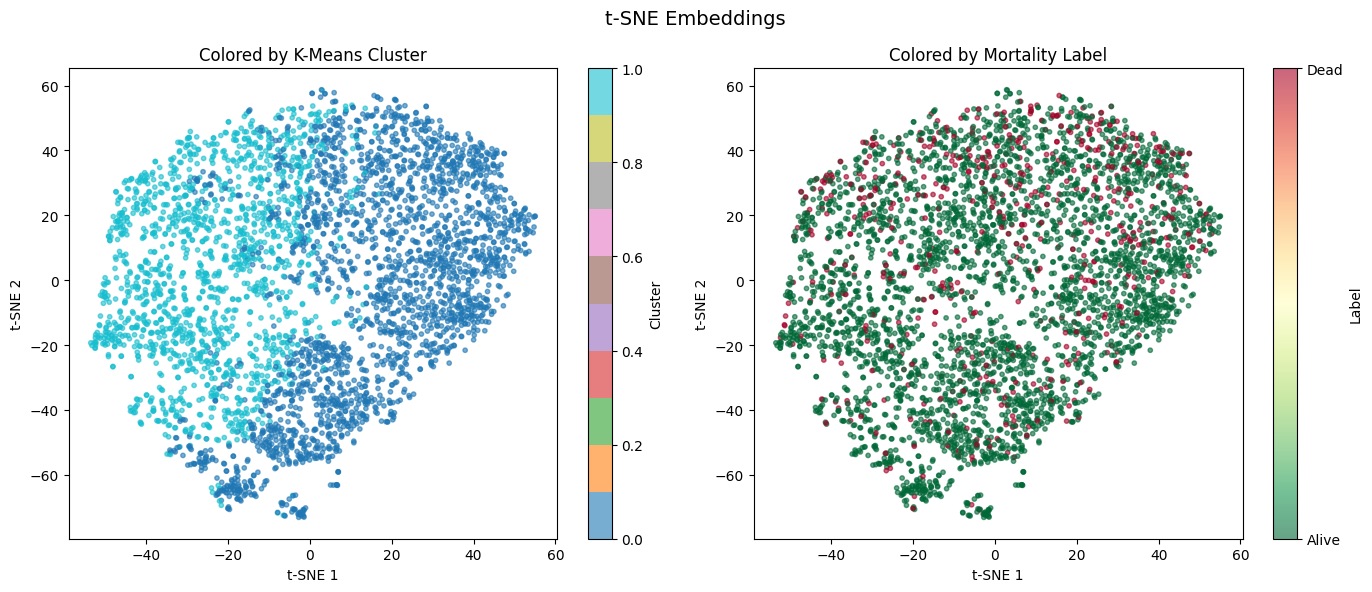

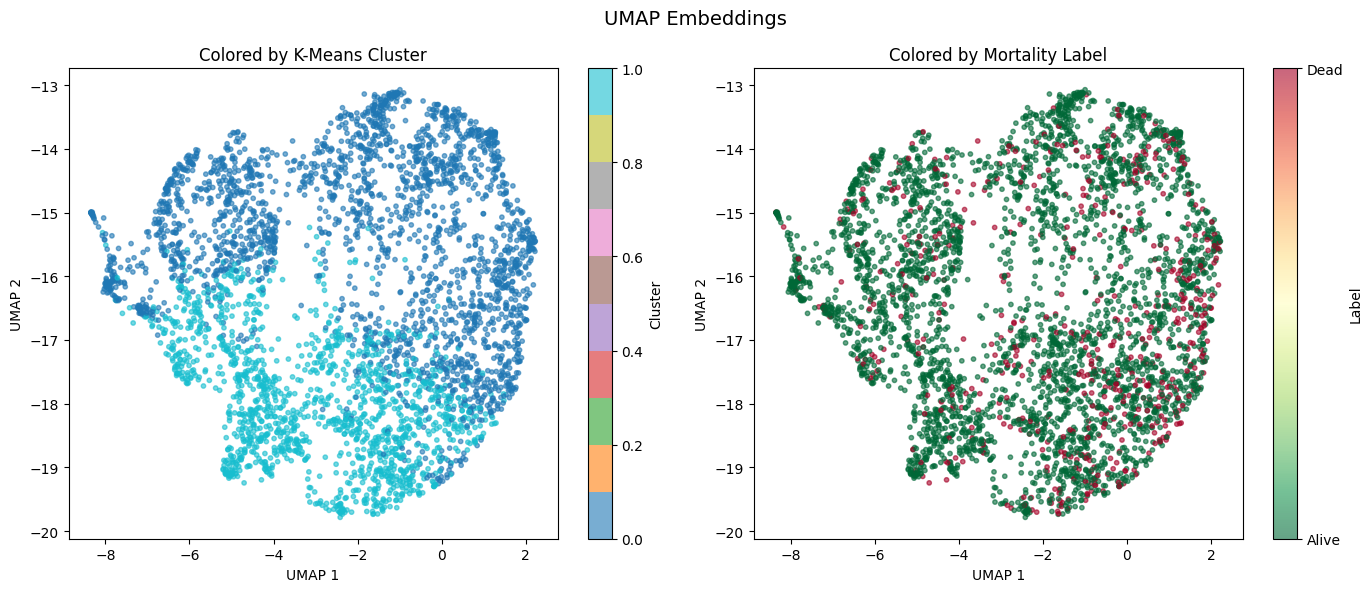

In [13]:
plot_embeddings(tsne_reduced, cluster_labels, test_labels, "t-SNE")
plot_embeddings(umap_reduced, cluster_labels, test_labels, "UMAP")